# Completed Random Forest COVID-19 Case Study
All requested cleaning and visualization exercises are completed, with a logistic regression comparison added as requested. The supplied file has 2,218 rows; 88 unknown target labels are excluded, leaving 2,130 labeled rows. The modeled outcome has three classes. Data-derived results replace hard-coded claims and labels from the template.

Notebook changes: Graphviz replaced by Matplotlib; typo `global_number` resolved to `global_num`; cleaning demonstrated without imputing targets; identifiers and outcome dates excluded from predictors; preprocessing fitted only on training folds; three-class confusion matrices corrected; importance ranked across all features. Review the saved outputs and limitations before submitting.

## Random Forest

Random Forest is an ensemble of Decision Trees. With a few exceptions, a `RandomForestClassifier` has all the hyperparameters of a `DecisionTreeClassifier` (to control how trees are grown), plus all the hyperparameters of a `BaggingClassifier` to control the ensemble itself.

The Random Forest algorithm introduces extra randomness when growing trees; instead of searching for the very best feature when splitting a node, it searches for the best feature among a random subset of features. This results in a greater tree diversity, which (once again) trades a higher bias for a lower variance, generally yielding an overall better model. The following `BaggingClassifier` is roughly equivalent to the previous `RandomForestClassifier`. Run the cell below to visualize a single estimator from a random forest model, using the Iris dataset to classify the data into the appropriate species.

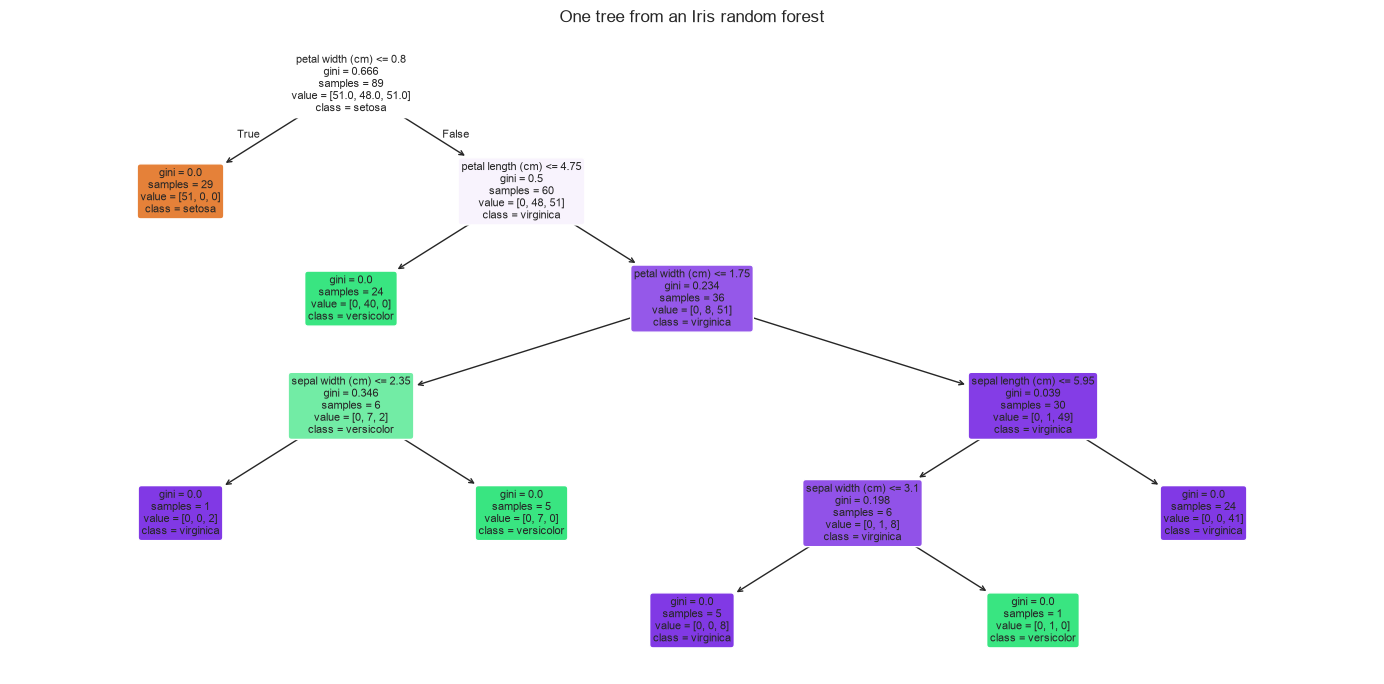

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, log_loss)
sns.set_theme(style='whitegrid')
iris = load_iris()
model = RandomForestClassifier(n_estimators=10, random_state=1)
model.fit(iris.data, iris.target)
estimator = model.estimators_[5]
fig, ax = plt.subplots(figsize=(14,7))
plot_tree(estimator, feature_names=iris.feature_names, class_names=iris.target_names,
          rounded=True, filled=True, fontsize=8, ax=ax)
ax.set_title('One tree from an Iris random forest')
plt.tight_layout(); plt.show()

Notice how each split seperates the data into buckets of similar observations. This is a single tree and a relatively simple classification dataset, but the same method is used in a more complex dataset with greater depth to the trees.

## Coronavirus: historical classification exercise
This case study uses the supplied historical South Korean patient dataset to classify recorded patient **state** (isolated, released, deceased). This is a retrospective snapshot task, not a validated prognosis model or an estimate of eventual mortality. Isolated patients have unresolved outcomes at the snapshot.

The CSV's observed confirmation dates span January 20–March 18, 2020. This differs from the assignment's introductory date description. Original data attribution: the Springboard-provided South Korea coronavirus dataset, described in the original notebook as sourced from Kaggle's DS4C dataset. Historical public-health advice in the template has been omitted because it is unnecessary for this modeling exercise.

First, please load the needed packages and modules into Python. Next, load the data into a pandas dataframe for ease of use.

In [2]:
# All imports are consolidated above. No Graphviz or Plotly installation is needed.
pd.set_option('display.max_columns', None)

In [3]:
url = 'SouthKoreacoronavirusdataset/PatientInfo.csv'
df = pd.read_csv(url)
raw_df = df.copy()
print('Confirmation dates:', pd.to_datetime(df['confirmed_date'],errors='coerce').min(), 'to',pd.to_datetime(df['confirmed_date'],errors='coerce').max())
df.head()

Confirmation dates: 2020-01-20 00:00:00 to 2020-03-18 00:00:00


,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,symptom_onset_date,confirmed_date,released_date,deceased_date,state
0,1000000001,2.0,male,1964.0,50s,Korea,Seoul,Gangseo-gu,NaN,overseas inflow,1.0,NaN,75.0,2020-01-22,2020-01-23,2020-02-05,NaN,released
1,1000000002,5.0,male,1987.0,30s,Korea,Seoul,Jungnang-gu,NaN,overseas inflow,1.0,NaN,31.0,NaN,2020-01-30,2020-03-02,NaN,released
2,1000000003,6.0,male,1964.0,50s,Korea,Seoul,Jongno-gu,NaN,contact with patient,2.0,2.002000e+09,17.0,NaN,2020-01-30,2020-02-19,NaN,released
3,1000000004,7.0,male,1991.0,20s,Korea,Seoul,Mapo-gu,NaN,overseas inflow,1.0,NaN,9.0,2020-01-26,2020-01-30,2020-02-15,NaN,released
4,1000000005,9.0,female,1992.0,20s,Korea,Seoul,Seongbuk-gu,NaN,contact with patient,2.0,1.000000e+09,2.0,NaN,2020-01-31,2020-02-24,NaN,released


In [4]:
df.shape

(2218, 18)

In [5]:
#Counts of null values 
na_df=pd.DataFrame(df.isnull().sum().sort_values(ascending=False)).reset_index()
na_df.columns = ['VarName', 'NullCount']
na_df[(na_df['NullCount']>0)]

,VarName,NullCount
0,disease,2199
1,deceased_date,2186
2,infection_order,2176
3,symptom_onset_date,2025
4,released_date,1995
5,contact_number,1807
6,infected_by,1749
7,infection_case,1055
8,global_num,904
9,birth_year,454


In [6]:
#counts of response variable values
df.state.value_counts()

state
isolated    1791
released     307
deceased      32
Name: count, dtype: int64

 **<font color='teal'> Create a new column named 'n_age' which is the calculated age based on the birth year column.</font>**

In [7]:
# Age at the 2020 snapshot, not at the current calendar year.
df['n_age'] = 2020 - pd.to_numeric(df['birth_year'],errors='coerce')
print(df[['birth_year','age','n_age']].head())
assert df['n_age'].dropna().between(0,120).all()

   birth_year  age  n_age
0      1964.0  50s   56.0
1      1987.0  30s   33.0
2      1964.0  50s   56.0
3      1991.0  20s   29.0
4      1992.0  20s   28.0


### Handle Missing Values

 **<font color='teal'> Print the number of missing values by column.</font>**

In [8]:
print(df.isna().sum().sort_values(ascending=False))

disease               2199
deceased_date         2186
infection_order       2176
symptom_onset_date    2025
released_date         1995
contact_number        1807
infected_by           1749
infection_case        1055
global_num             904
n_age                  454
birth_year             454
age                    261
sex                    145
confirmed_date         141
state                   88
city                    65
province                 0
country                  0
patient_id               0
dtype: int64


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          2218 non-null   int64  
 1   global_num          1314 non-null   float64
 2   sex                 2073 non-null   str    
 3   birth_year          1764 non-null   float64
 4   age                 1957 non-null   str    
 5   country             2218 non-null   str    
 6   province            2218 non-null   str    
 7   city                2153 non-null   str    
 8   disease             19 non-null     object 
 9   infection_case      1163 non-null   str    
 10  infection_order     42 non-null     float64
 11  infected_by         469 non-null    float64
 12  contact_number      411 non-null    float64
 13  symptom_onset_date  193 non-null    str    
 14  confirmed_date      2077 non-null   str    
 15  released_date       223 non-null    str    
 16  deceased_date    

 **<font color='teal'> Fill the 'disease' missing values with 0 and remap the True values to 1.</font>**

In [10]:
# Assignment convention: 1 = recorded True; 0 includes undocumented disease.
df['disease'] = df['disease'].eq(True).astype(int)
print(df['disease'].value_counts())
# Keep the pre-imputation copy for leakage-safe modeling pipelines.
model_source = df.copy()

disease
0    2199
1      19
Name: count, dtype: int64


 **<font color='teal'> Fill null values in the following columns with their mean: 'global_number','birth_year','infection_order','infected_by'and 'contact_number'</font>**

In [11]:
# The file calls this field global_num, not global_number.
# Establish the labeled split before estimating any imputation values.
labeled_index = df.index[df['state'].notna()]
train_index, test_index = train_test_split(labeled_index, test_size=0.2,
    random_state=1, stratify=df.loc[labeled_index,'state'])
mean_columns = ['global_num','birth_year','infection_order','infected_by','contact_number']
training_means = df.loc[train_index, mean_columns].mean()
df[mean_columns] = df[mean_columns].fillna(training_means)
print('Means learned from training rows only:')
print(training_means)

Means learned from training rows only:
global_num         4.431176e+03
birth_year         1.975192e+03
infection_order    2.411765e+00
infected_by        2.664355e+09
contact_number     2.579939e+01
dtype: float64


 **<font color='teal'> Fill the rest of the missing values with any method.</font>**

In [12]:
# Explicit schema supports object, str, and nullable string columns.
# Preserve unknown target labels for exclusion from supervised learning.
df['n_age'] = df['n_age'].fillna(model_source.loc[train_index, 'n_age'].mean())
text_columns = [
    'sex', 'age', 'country', 'province', 'city', 'infection_case',
    'symptom_onset_date', 'confirmed_date', 'released_date', 'deceased_date'
]
for column in text_columns:
    df[column] = df[column].astype(object).fillna('Unknown')
print('Cleanup revision 3: explicit text columns filled.')
print('Missing state labels are intentionally retained for exclusion from supervised learning.')

Cleanup revision 3: explicit text columns filled.
Missing state labels are intentionally retained for exclusion from supervised learning.


 **<font color='teal'> Check for any remaining null values.</font>**

In [13]:
print(df.isna().sum())
missing = df.drop(columns='state').isna().sum()
assert missing.sum() == 0, f'Columns still containing missing values: {missing[missing > 0].to_dict()}'
print('Unknown target labels:', df['state'].isna().sum())

patient_id             0
global_num             0
sex                    0
birth_year             0
age                    0
country                0
province               0
city                   0
disease                0
infection_case         0
infection_order        0
infected_by            0
contact_number         0
symptom_onset_date     0
confirmed_date         0
released_date          0
deceased_date          0
state                 88
n_age                  0
dtype: int64
Unknown target labels: 88


In [14]:
df.head()

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,symptom_onset_date,confirmed_date,released_date,deceased_date,state,n_age
0,1000000001,2.0,male,1964.0,50s,Korea,Seoul,Gangseo-gu,0,overseas inflow,1.0,2.664355e+09,75.0,2020-01-22,2020-01-23,2020-02-05,Unknown,released,56.0
1,1000000002,5.0,male,1987.0,30s,Korea,Seoul,Jungnang-gu,0,overseas inflow,1.0,2.664355e+09,31.0,Unknown,2020-01-30,2020-03-02,Unknown,released,33.0
2,1000000003,6.0,male,1964.0,50s,Korea,Seoul,Jongno-gu,0,contact with patient,2.0,2.002000e+09,17.0,Unknown,2020-01-30,2020-02-19,Unknown,released,56.0
3,1000000004,7.0,male,1991.0,20s,Korea,Seoul,Mapo-gu,0,overseas inflow,1.0,2.664355e+09,9.0,2020-01-26,2020-01-30,2020-02-15,Unknown,released,29.0
4,1000000005,9.0,female,1992.0,20s,Korea,Seoul,Seongbuk-gu,0,contact with patient,2.0,1.000000e+09,2.0,Unknown,2020-01-31,2020-02-24,Unknown,released,28.0


Remove date columns from the data.


In [15]:
df = df.drop(['symptom_onset_date','confirmed_date','released_date','deceased_date'],axis =1)

Review the count of unique values by column.

In [16]:
print(df.nunique())

patient_id         2218
global_num         1304
sex                   3
birth_year           97
age                  12
country               4
province             17
city                135
disease               2
infection_case       17
infection_order       7
infected_by         207
contact_number       73
state                 3
n_age                97
dtype: int64


Review the percent of unique values by column.

In [17]:
print(df.nunique()/df.shape[0])

patient_id         1.000000
global_num         0.587917
sex                0.001353
birth_year         0.043733
age                0.005410
country            0.001803
province           0.007665
city               0.060866
disease            0.000902
infection_case     0.007665
infection_order    0.003156
infected_by        0.093327
contact_number     0.032913
state              0.001353
n_age              0.043733
dtype: float64


Review the range of values per column.

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,2218.0,4.014678e+09,2.192419e+09,1.000000e+09,1.700000e+09,6.001000e+09,6.004000e+09,7.000000e+09
global_num,2218.0,4.569591e+03,2.214764e+03,1.000000e+00,4.205250e+03,4.431176e+03,5.900250e+03,8.717000e+03
birth_year,2218.0,1.975030e+03,1.731143e+01,1.916000e+03,1.965000e+03,1.975192e+03,1.988000e+03,2.020000e+03
disease,2218.0,8.566276e-03,9.217769e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
infection_order,2218.0,2.409378e+00,1.715252e-01,1.000000e+00,2.411765e+00,2.411765e+00,2.411765e+00,6.000000e+00
infected_by,2218.0,2.650914e+09,7.220996e+08,1.000000e+09,2.664355e+09,2.664355e+09,2.664355e+09,6.113000e+09
contact_number,2218.0,2.548986e+01,3.917679e+01,0.000000e+00,2.579939e+01,2.579939e+01,2.579939e+01,1.160000e+03
n_age,2218.0,4.496978e+01,1.731143e+01,0.000000e+00,3.200000e+01,4.480832e+01,5.500000e+01,1.040000e+02


### Check for duplicated rows

In [19]:
duplicateRowsDF = df[df.duplicated()]
duplicateRowsDF

,patient_id,global_num,sex,birth_year,age,country,province,city,disease,infection_case,infection_order,infected_by,contact_number,state,n_age


Print the categorical columns and their associated levels.

In [20]:
dfo = df[[c for c in text_columns + ['state'] if c in df.columns]]
dfo.shape
#get levels for all variables
vn = pd.DataFrame(dfo.nunique()).reset_index()
vn.columns = ['VarName', 'LevelsCount']
vn.sort_values(by='LevelsCount', ascending =False)
vn

,VarName,LevelsCount
0,sex,3
1,age,12
2,country,4
3,province,17
4,city,135
5,infection_case,17
6,state,3


**<font color='teal'> Plot the correlation heat map for the features.</font>**

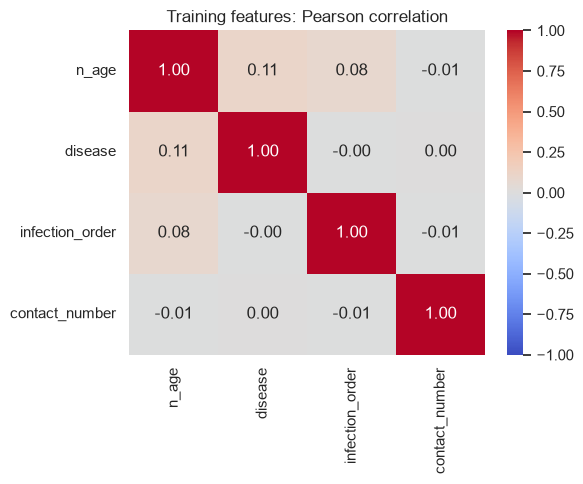

In [21]:
# Inspect training data only. Identifier correlations have no substantive meaning.
numeric_features = ['n_age','disease','infection_order','contact_number']
corr = df.loc[train_index,numeric_features].corr()
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr,annot=True,fmt='.2f',vmin=-1,vmax=1,cmap='coolwarm',ax=ax)
ax.set_title('Training features: Pearson correlation')
plt.tight_layout();plt.show()

**<font color='teal'> Plot the boxplots to check for outliers. </font>**

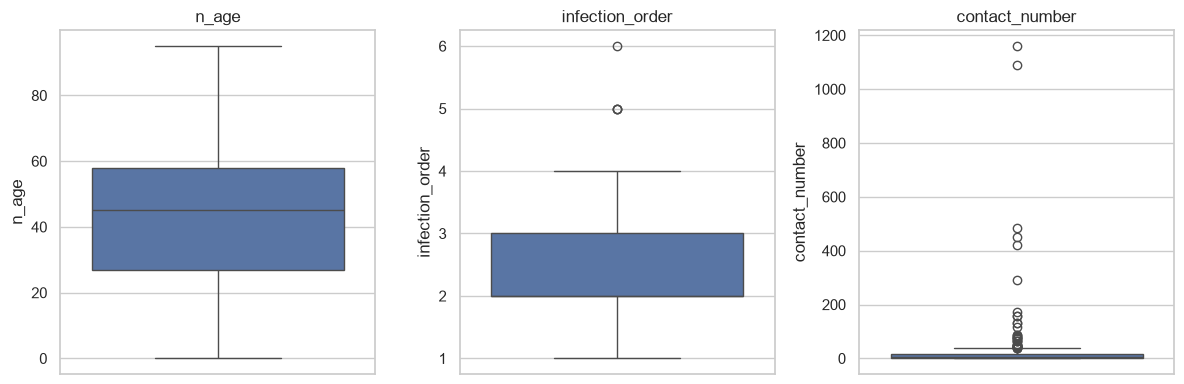

             n_age  infection_order  contact_number
count  1346.000000        34.000000      329.000000
mean     44.808321         2.411765       25.799392
std      19.561789         1.328422       99.915677
min       0.000000         1.000000        0.000000
25%      27.000000         2.000000        2.000000
50%      45.000000         2.000000        5.000000
75%      58.000000         3.000000       17.000000
max      95.000000         6.000000     1160.000000


In [22]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
for ax, col in zip(axes,['n_age','infection_order','contact_number']):
    sns.boxplot(y=model_source.loc[train_index,col],ax=ax)
    ax.set_title(col)
plt.tight_layout();plt.show()
print(model_source.loc[train_index,['n_age','infection_order','contact_number']].describe())
# Keep plausible extremes: statistical outliers are not automatically errors.

**<font color='teal'> Create dummy features for object type features. </font>**

In [23]:
# Define dummy encoding now; fit it only on training data below and within CV.
categorical_features = ['sex','country','province','city','infection_case']
features = numeric_features + categorical_features
X = model_source.loc[labeled_index,features].copy()
# Normalize missing text values for scikit-learn pipeline imputation.
for column in categorical_features:
    X[column] = X[column].astype(object)
    X[column] = X[column].where(X[column].notna(), np.nan)
y = model_source.loc[labeled_index,'state'].copy()
# Excluded: patient_id/global_num/infected_by (identifiers), dates (including
# direct outcomes), and birth_year/age (redundant with n_age).
# The requested ID mean-filling above demonstrates cleaning, not modeling.
categorical_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='constant',fill_value='Unknown')),
    ('encode',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
numeric_pipe = Pipeline([
    ('impute',SimpleImputer(strategy='mean')),
    ('scale',StandardScaler())])
preprocessor = ColumnTransformer([
    ('numeric',numeric_pipe,numeric_features),
    ('categorical',categorical_pipe,categorical_features)],
    verbose_feature_names_out=False)
assert 'state' not in features

### Split the data into test and train subsamples

In [24]:
# Reuse the original split indices: 80/20 with seed 1, adding stratification.
X_train, X_test = X.loc[train_index], X.loc[test_index]
y_train, y_test = y.loc[train_index], y.loc[test_index]
print('Train and test:',X_train.shape,X_test.shape)
print(pd.DataFrame({'train':y_train.value_counts(),'test':y_test.value_counts()}))
assert set(train_index).isdisjoint(test_index)
assert y_train.notna().all() and y_test.notna().all()

Train and test: (1704, 9) (426, 9)
          train  test
state                
isolated   1433   358
released    245    62
deceased     26     6


### Scale data to prep for model creation

In [25]:
# A pipeline keeps imputation, scaling and encoding within each training fold.
# Scaling is useful for logistic regression; forests do not require it.
prepared = clone(preprocessor).fit(X_train)
X_train_scaled = prepared.transform(X_train)
X_test_scaled = prepared.transform(X_test)
print('Encoded feature count:',X_train_scaled.shape[1])
assert np.isfinite(X_train_scaled).all() and np.isfinite(X_test_scaled).all()

Encoded feature count: 176


In [26]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=1)
candidates = {
    'Majority baseline': DummyClassifier(strategy='most_frequent'),
    'Random forest': RandomForestClassifier(n_estimators=300,random_state=1,n_jobs=1),
    'Logistic regression': LogisticRegression(max_iter=3000,random_state=1)
}
models, results, cv_results = {}, [], []
for name, estimator in candidates.items():
    pipeline = Pipeline([('preprocess',clone(preprocessor)),('model',clone(estimator))])
    scores = cross_validate(pipeline,X_train,y_train,cv=cv,
                scoring=['accuracy','balanced_accuracy','f1_macro'])
    cv_results.append({'model':name,'cv_accuracy':scores['test_accuracy'].mean(),
        'cv_balanced_accuracy':scores['test_balanced_accuracy'].mean(),
        'cv_macro_f1':scores['test_f1_macro'].mean(),
        'cv_macro_f1_std':scores['test_f1_macro'].std()})
    models[name] = pipeline.fit(X_train,y_train)
cv_table = pd.DataFrame(cv_results).set_index('model')
print(cv_table.round(4))
chosen_model_name = cv_table.loc[['Random forest','Logistic regression'],'cv_macro_f1'].idxmax()
print('Model selected by training CV macro F1:',chosen_model_name)

                     cv_accuracy  cv_balanced_accuracy  cv_macro_f1  \
model                                                                 
Majority baseline         0.8410                0.3333       0.3045   
Random forest             0.8410                0.6684       0.6906   
Logistic regression       0.8556                0.6255       0.6687   

                     cv_macro_f1_std  
model                                 
Majority baseline             0.0002  
Random forest                 0.0126  
Logistic regression           0.0269  
Model selected by training CV macro F1: Random forest


### Fit and evaluate Random Forest Classifier

The forest was fitted above with 300 trees. Evaluate observed results rather than assuming the template's 80% accuracy. Because most labels are isolated, macro F1, balanced accuracy and per-class recall are essential alongside overall accuracy.

In [27]:
class_names = sorted(y.unique().tolist())
for name, fitted in models.items():
    pred = fitted.predict(X_test)
    probs = fitted.predict_proba(X_test)
    results.append({'model':name,'train_accuracy':fitted.score(X_train,y_train),
        'test_accuracy':accuracy_score(y_test,pred),
        'balanced_accuracy':balanced_accuracy_score(y_test,pred),
        'macro_f1':f1_score(y_test,pred,average='macro',zero_division=0),
        'weighted_f1':f1_score(y_test,pred,average='weighted',zero_division=0),
        'log_loss':log_loss(y_test,probs,labels=fitted.classes_)})
    print('\n'+name)
    print(classification_report(y_test,pred,labels=class_names,digits=4,zero_division=0))
comparison = pd.DataFrame(results).set_index('model')
print(comparison.round(4))
model_res = models['Random forest']
clf = model_res.named_steps['model']
y_pred = model_res.predict(X_test)
y_pred_prob = model_res.predict_proba(X_test)
cm = confusion_matrix(y_test,y_pred,labels=class_names)


Majority baseline
              precision    recall  f1-score   support

    deceased     0.0000    0.0000    0.0000         6
    isolated     0.8404    1.0000    0.9133       358
    released     0.0000    0.0000    0.0000        62

    accuracy                         0.8404       426
   macro avg     0.2801    0.3333    0.3044       426
weighted avg     0.7062    0.8404    0.7675       426


Random forest
              precision    recall  f1-score   support

    deceased     0.8571    1.0000    0.9231         6
    isolated     0.8679    0.9358    0.9005       358
    released     0.3333    0.1774    0.2316        62

    accuracy                         0.8263       426
   macro avg     0.6861    0.7044    0.6851       426
weighted avg     0.7899    0.8263    0.8035       426


Logistic regression
              precision    recall  f1-score   support

    deceased     1.0000    1.0000    1.0000         6
    isolated     0.8596    0.9749    0.9136       358
    released     0.3

### Create Confusion Matrix Plots
Confusion matrices are great ways to review your model performance for a multi-class classification problem. Being able to identify which class the misclassified observations end up in is a great way to determine if you need to build additional features to improve your overall model. In the example below we plot a regular counts confusion matrix as well as a weighted percent confusion matrix. The percent confusion matrix is particulary helpful when you have unbalanced class sizes.

In [28]:
# Use actual class order; missing is not a clinical outcome class.
class_names = models['Random forest'].classes_.tolist()
print(class_names)

['deceased', 'isolated', 'released']


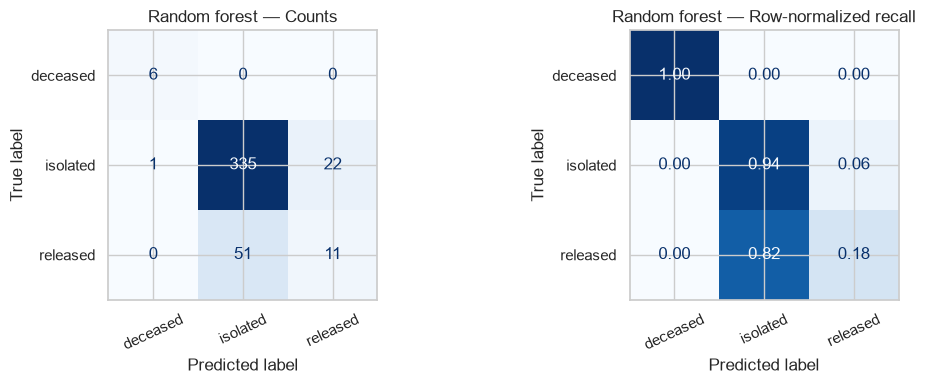

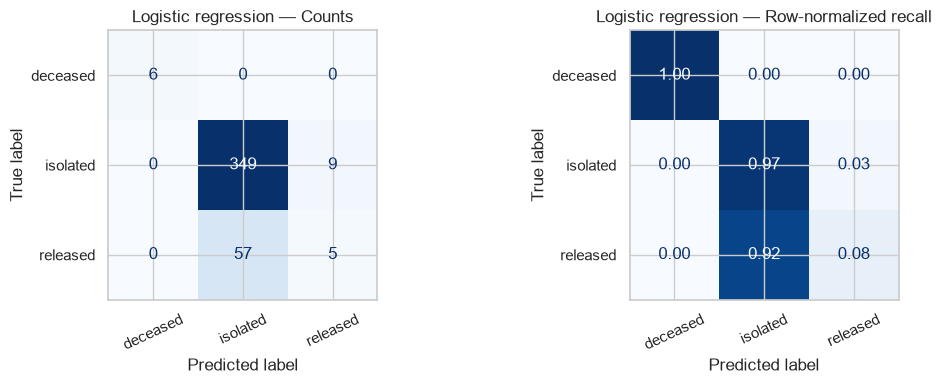

In [29]:
for name in ['Random forest','Logistic regression']:
    pred = models[name].predict(X_test)
    fig, axes = plt.subplots(1,2,figsize=(11,4))
    for ax, norm, title in zip(axes,[None,'true'],['Counts','Row-normalized recall']):
        ConfusionMatrixDisplay.from_predictions(y_test,pred,labels=class_names,
            display_labels=class_names,normalize=norm,ax=ax,cmap='Blues',
            colorbar=False,values_format='d' if norm is None else '.2f')
        ax.set_title(name+' — '+title)
        ax.tick_params(axis='x',rotation=25)
    plt.tight_layout();plt.show()

### Plot feature importances
The random forest algorithm can be used as a regression or classification model. In either case it tends to be a bit of a black box, where understanding what's happening under the hood can be difficult. Plotting the feature importances is one way that you can gain a perspective on which features are driving the model predictions.

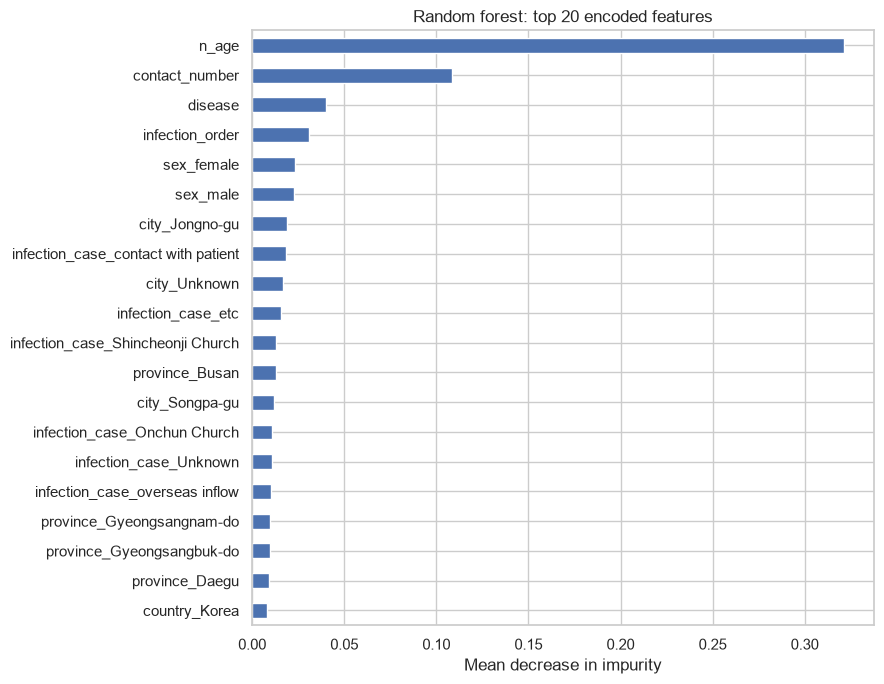

n_age                                  0.321526
contact_number                         0.108522
disease                                0.040106
infection_order                        0.031095
sex_female                             0.023012
sex_male                               0.022560
city_Jongno-gu                         0.018857
infection_case_contact with patient    0.018566
city_Unknown                           0.016510
infection_case_etc                     0.015811
dtype: float64


In [30]:
feature_names = model_res.named_steps['preprocess'].get_feature_names_out()
feature_importance = pd.Series(clf.feature_importances_,index=feature_names)
# Sort all features first, then choose the top 20 (not the first 30 columns).
top = feature_importance.nlargest(20).sort_values()
fig, ax = plt.subplots(figsize=(9,7))
top.plot.barh(ax=ax)
ax.set(xlabel='Mean decrease in impurity',title='Random forest: top 20 encoded features')
plt.tight_layout();plt.show()
print(feature_importance.nlargest(10))
comparison.to_csv('Model_Comparison.csv')
cv_table.to_csv('Cross_Validation_Results.csv')

## Interpretation and limitations
Compare the forest, logistic regression and majority baseline in the tables above. A high accuracy can largely reflect the dominant isolated class. The held-out deceased class has very few observations, making its recall and F1 highly unstable. Neither weighted F1 nor overall accuracy is sufficient evidence of a useful rare-outcome classifier.

Feature importance measures predictive association, not causation. Impurity importance can favor continuous or high-cardinality predictors; correlated features can share importance. Geographic patterns may reflect reporting and follow-up differences. The disease flag is mostly undocumented: filling missing values with zero follows the exercise but does not establish absence of a condition.

This snapshot mixes unresolved isolated cases with resolved outcomes, with varying follow-up. Infection-case, contact and tracing features might not be available at a prospective prediction time. Dropping release/death dates prevents direct outcome leakage, but does not establish a prospective clinical design. A defensible future study needs a defined prediction time and horizon, features available then, temporal/group-aware validation, reliable outcomes and sufficient minority-class cases. These models are educational and do not establish clinical readiness or eventual mortality risk.

Unknown states were excluded rather than manufactured as a fourth class. Preprocessing and cross-validation use training rows only. No test-driven tuning was performed. Age is an approximate year difference at the 2020 snapshot, not exact birthday-based age.

### Computed findings

| Model | Test accuracy | Balanced accuracy | Macro F1 |
|---|---:|---:|---:|
| Majority baseline | 84.04% | 33.33% | 0.3044 |
| Random forest | 82.63% | 70.44% | 0.6851 |
| Logistic regression | 84.51% | 68.52% | 0.6817 |

Training-only CV macro F1 selects the forest (0.6891 vs logistic regression 0.6687). Logistic regression has higher test accuracy and lower log loss, while the forest has slightly higher test macro F1 and balanced accuracy. This is a trade-off, not evidence that the forest wins every metric.

The forest correctly identifies only **11 of 62 released patients (17.74% recall)**; logistic regression identifies **5 of 62 (8.06%)**. Both identify the six deceased test cases, but six observations are too few to establish reliable rare-outcome performance, particularly given the disease-recording concern below. The forest's training accuracy is 97.07% versus 82.63% on test data, indicating substantial overfitting risk. A useful follow-up would tune depth/minimum leaf size and class weighting within training CV, with a separately reserved final test set.

The largest forest impurity importances are approximate age (0.3215), contact count (0.1085), disease flag (0.0400), and infection order (0.0311). Sparse documentation and high-cardinality geography limit substantive interpretation.


## Sensitivity check: disease-recording bias

All 19 recorded True disease flags occur among deceased records. This does not prove leakage, but availability before the outcome is unverified. Compare training CV with this field excluded; this is a diagnostic, not test-driven model tuning.

In [31]:
print(pd.crosstab(raw_df['disease'].fillna('Undocumented'),raw_df['state']))
no_disease_preprocessor = clone(preprocessor)
no_disease_preprocessor.transformers = [
    ('numeric',clone(numeric_pipe),[c for c in numeric_features if c != 'disease']),
    ('categorical',clone(categorical_pipe),categorical_features)]
ablation_rows=[]
for name in ['Random forest','Logistic regression']:
    pipe=Pipeline([('preprocess',clone(no_disease_preprocessor)),('model',clone(candidates[name]))])
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=['f1_macro','balanced_accuracy'])
    ablation_rows.append({'model':name,'cv_macro_f1_without_disease':scores['test_f1_macro'].mean(),
        'cv_balanced_accuracy_without_disease':scores['test_balanced_accuracy'].mean()})
ablation=pd.DataFrame(ablation_rows).set_index('model')
print(ablation.round(4))


state         deceased  isolated  released
disease                                   
True                19         0         0
Undocumented        13      1791       307
                     cv_macro_f1_without_disease  \
model                                              
Random forest                              0.626   
Logistic regression                        0.580   

                     cv_balanced_accuracy_without_disease  
model                                                      
Random forest                                      0.6030  
Logistic regression                                0.5219  


The check cannot remove all reporting or follow-up bias. Verify feature timestamps and collection practices before interpreting this as prospective prediction. No model is recommended for clinical use from this case study. Original assignment/data: Springboard; solution prepared with ChatGPT assistance.

**Computed sensitivity:** Without the disease field, mean CV macro F1 falls from 0.6891 to **0.6264** for the forest and from 0.6687 to **0.5800** for logistic regression. This supports caution about relying on the documentation-sensitive field; it does not prove causal importance or confirm leakage.